### BAO Exercise

In [1]:
import numpy as np
from scipy.integrate import quad

# --- 1. DATA SETUP ---
# z_eff, DM/rd, err_M, DH/rd, err_H, corr
data_raw = np.array([
    [0.510, 13.588, 0.167, 21.863, 0.425, -0.459],
    [0.706, 17.351, 0.177, 19.455, 0.330, -0.404],
    [0.943, 21.576, 0.152, 17.641, 0.193, -0.416],
    [1.321, 27.601, 0.318, 14.176, 0.221, -0.434],
    [1.484, 30.512, 0.760, 12.817, 0.516, -0.500],
    [2.330, 38.988, 0.531,  8.632, 0.101, -0.431] 
])

# Constants
c_light = 299792.458 # km/s

# --- 2. MODEL DEFINITION ---
def get_theoretical_distances(Om, H0rd, z):
    """
    Returns theoretical [DM/rd, DH/rd] for a Flat LCDM model.
    """
    # Hubble expansion factor E(z)
    # Note: For flat universe, Omega_Lambda = 1 - Omega_m
    Ez = np.sqrt(Om * (1 + z)**3 + (1 - Om))
    
    # 1. Radial Distance: DH/rd = c / (H0*rd * E(z))
    # We fit H0*rd as a single parameter (let's call it A)
    DH_rd = c_light / (H0rd * Ez)
    
    # 2. Angular Distance: DM/rd = c / (H0*rd) * integral(1/E(z))
    # Define the integrand
    def integrand(z_prime):
        return 1.0 / np.sqrt(Om * (1 + z_prime)**3 + (1 - Om))
    
    # Integrate from 0 to z
    integral, error = quad(integrand, 0, z)
    DM_rd = (c_light / H0rd) * integral
    
    return np.array([DM_rd, DH_rd])

# --- 3. LOG LIKELIHOOD ---
def log_likelihood(theta):
    Om, H0rd = theta
    
    chi2_total = 0
    
    # Loop over each redshift bin in the data
    for row in data_raw:
        z, obs_DM, err_M, obs_DH, err_H, rho = row
        
        # Get Model predictions
        model_vals = get_theoretical_distances(Om, H0rd, z) # Returns [DM_model, DH_model]
        
        # Observation vector
        obs_vec = np.array([obs_DM, obs_DH])
        
        # Residual vector (Data - Model)
        diff = obs_vec - model_vals
        
        # Covariance Matrix construction
        # [ var_M       cov_MH ]
        # [ cov_MH      var_H  ]
        cov_MH = rho * err_M * err_H
        cov_matrix = np.array([
            [err_M**2, cov_MH],
            [cov_MH,   err_H**2]
        ])
        
        # Add to total Chi2:  R.T * C^-1 * R
        inv_cov = np.linalg.inv(cov_matrix)
        chi2_bin = diff @ inv_cov @ diff
        
        chi2_total += chi2_bin

    return -0.5 * chi2_total

# --- 4. LOG PRIOR & POSTERIOR ---
def log_prior(theta):
    Om, H0rd = theta
    # Uniform wide priors
    # Om between 0 and 1
    # H0rd typically around 10,000 km/s (70 km/s/Mpc * 150 Mpc)
    # Let's set wide range: 5,000 to 20,000
    if 0.0 < Om < 1.0 and 5000.0 < H0rd < 20000.0:
        return 0.0
    return -np.inf

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# Now 'log_posterior' is ready to be used by an MCMC sampler (like emcee).

In [2]:
!pip install emcee
!pip install emcee getdist

In [3]:
import emcee
import numpy as np

# 1. Initialize the "Hikers" (Walkers)
# We need to pick a starting point for them.
# Let's guess Om=0.3 and H0rd=10,000 to start.
n_walkers = 32   # The number of parallel hikers
n_dim = 2        # The number of parameters (Om, H0rd)

# Create a small ball of random starting positions around our guess
start_pos = [0.3, 10000.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

# 2. Set up the Sampler (The Engine)
# We tell emcee: "Use 'n_walkers', exploring 'n_dim' dimensions, 
# using the map 'log_posterior'"
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior)

# 3. Run the MCMC (The Exploration)
# We run it for 5,000 steps.
print("Running MCMC chains...")
sampler.run_mcmc(start_pos, 5000, progress=True)

print("Done!")

Running MCMC chains...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:53<00:00, 93.57it/s]

Done!


In [4]:
# 1. Extract the chain
# We discard the first 100 steps (burn-in) where walkers were finding the peak.
# We "thin" by 15 (take every 15th step) to make the samples independent.
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

# 2. Calculate Statistics
# mean = average position (Best guess)
# std = standard deviation (Error bar)
om_mcmc = np.percentile(flat_samples[:, 0], [16, 50, 84])
h0rd_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])

# The percentile method gives the median (50%) and the 1-sigma range (16-84%)
print(f"Omega_m = {om_mcmc[1]:.3f} (+{om_mcmc[2]-om_mcmc[1]:.3f} / -{om_mcmc[1]-om_mcmc[0]:.3f})")
print(f"H0 * rd = {h0rd_mcmc[1]:.0f} (+{h0rd_mcmc[2]-h0rd_mcmc[1]:.0f} / -{h0rd_mcmc[1]-h0rd_mcmc[0]:.0f})")

# 3. Check Convergence (Gelman-Rubin)
# [cite_start]The exercise asks you to verify convergence[cite: 40]. 
# A simple check is the autocorrelation time.
tau = sampler.get_autocorr_time()
print(f"Autocorrelation time: {tau}")
# If the number of steps (5000) is >> 50 * tau, you are converged.

Omega_m = 0.291 (+0.010 / -0.009)
H0 * rd = 10220 (+82 / -85)
Autocorrelation time: [32.45336087 35.74036015]


In [5]:
import numpy as np

def gelman_rubin(chain):
    """
    Calculates the Gelman-Rubin statistic R_hat.
    Chain shape: (n_steps, n_walkers, n_params)
    """
    n_steps, n_walkers, n_params = chain.shape
    
    # 1. Calculate the mean of each chain
    mean_per_chain = np.mean(chain, axis=0)      # Shape: (n_walkers, n_params)
    mean_overall = np.mean(mean_per_chain, axis=0) # Shape: (n_params,)
    
    # 2. Calculate Between-Chain Variance (B)
    # B = n_steps / (n_walkers - 1) * sum((mean_chain - mean_overall)^2)
    B = (n_steps / (float(n_walkers) - 1.0)) * np.sum((mean_per_chain - mean_overall)**2, axis=0)
    
    # 3. Calculate Within-Chain Variance (W)
    # Variance of each chain individually
    var_per_chain = np.var(chain, axis=0, ddof=1)
    W = np.mean(var_per_chain, axis=0)
    
    # 4. Calculate Weighted Variance (Var_hat)
    # Var_hat = (1 - 1/n) * W + (1/n) * B
    Var_hat = ((n_steps - 1.0) / n_steps) * W + (B / n_steps)
    
    # 5. R_hat
    R_hat = np.sqrt(Var_hat / W)
    return R_hat

# Get the chain from the sampler (discarding burn-in)
# We use the raw chain (steps, walkers, params) for this calculation
chain = sampler.get_chain(discard=100, thin=1, flat=False)
r_hat_values = gelman_rubin(chain)

print(f"Gelman-Rubin R-hat for Omega_m: {r_hat_values[0]:.4f}")
print(f"Gelman-Rubin R-hat for H0*rd:   {r_hat_values[1]:.4f}")

Gelman-Rubin R-hat for Omega_m: 1.0023
Gelman-Rubin R-hat for H0*rd:   1.0024


Removed no burn in

--- 1D Marginals ---
\Omega_m = 0.2916\pm 0.0094
H_0 r_d = 10220\pm 84

--- Correlation Matrix ---
[[ 1.         -0.94315989]
 [-0.94315989  1.        ]]
Correlation coefficient: -0.943


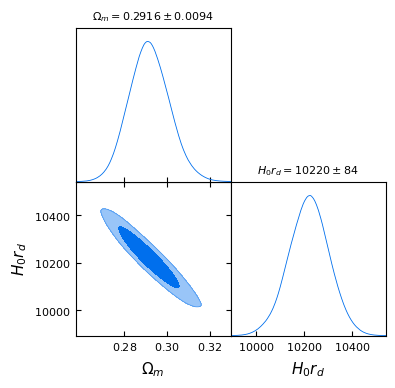

In [6]:
from getdist import plots, MCSamples

# 1. Prepare data for GetDist
# Get flat samples again (merged chains)
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

# Define parameter names and labels for the plot
names = ['Om', 'H0rd']
labels = [r'\Omega_m', r'H_0 r_d']

# Create an MCSamples object
samples_gd = MCSamples(samples=flat_samples, names=names, labels=labels, label='DESI BAO')

# 2. Print Statistics (Mean, Std, Correlation)
print("\n--- 1D Marginals ---")
# This prints mean and standard deviation
print(samples_gd.getInlineLatex('Om'))
print(samples_gd.getInlineLatex('H0rd'))

print("\n--- Correlation Matrix ---")
# This gives the correlation coefficient between Om and H0rd
cov_mat = samples_gd.cov()
corr_mat = samples_gd.getCorrelationMatrix()
print(corr_mat)
print(f"Correlation coefficient: {corr_mat[0,1]:.3f}")

# 3. Plotting
g = plots.get_subplot_plotter()
g.triangle_plot(samples_gd, filled=True, title_limit=1)
# If running in a notebook, this will display the plot automatically

### Summary and Comment


* We took the DESI DR2 BAO measurements (radial D_H and angular D_M distances) for 6 redshift bins. and  we constructed the Covariance Matrix to account for the correlation between the two measurements at each redshift.*
* We assumed a Flat Universe (Ωk = 0), where the expansion history is governed by a single density parameter, \Omega_m, and the scale is set by the combined parameter H_0 r_d.
*  We built a Posterior function (Likelihood $\times$ Prior) and used Markov Chain Monte Carlo to explore the parameter space, in order to find the most probable values.
*  We checked for convergence (using the Gelman-Rubin $\hat{R}$ statistic) to ensure our results are reasonable.
* Finally we generated the plots


**1. Matter Density**
* **Result:** $\Omega_m \approx 0.292 \pm 0.009$
*  This result provides a high-precision constraint ($\sim 3\%$) on the matter content of the Universe using only geometric galaxy data. The accepted values ($\Omega_m \approx 0.315$) are close but outside our error estimates (but we didnt have a lot of data, also measurements could be imperfect). Nevertheless it shows that the $\Lambda$CDM model describes the late-time Universe well. 


**2. The Acoustic Scale Parameter**

* **Result:** $H_0 r_d \approx 10220 \pm 84$ km/s
    * To recover the Planck-CMB Hubble constant ($H_0 \approx 67$ km/s/Mpc), the sound horizon must be the standard $r_d \approx 147$ Mpc.
    * To recover the local Supernova Hubble constant ($H_0 \approx 73$ km/s/Mpc), the sound horizon would need to be significantly smaller ($r_d \approx 140$ Mpc).

**3. Parameter Degeneracy**
* **Result:** Correlation Coefficient $\approx -0.94$
*   An increase in matter density $\Omega_m$ (which slows expansion) can be nearly perfectly compensated by a decrease in the scale factor $H_0 r_d$. This "banana-shaped" degeneracy confirms that BAO data needs external data (like CMB or SNIa) to break the degeneracy and pin down $H_0$ and $r_d$ individually.


### Bonus 1

relaxing the flatness condition

In [7]:
import numpy as np
from scipy.integrate import quad
import emcee

# --- 1. NEW MODEL WITH CURVATURE ---
def get_theoretical_distances_curved(Om, OL, H0rd, z):
    """
    Returns theoretical [DM/rd, DH/rd] for a Non-Flat LCDM model.
    Parameters: Omega_m, Omega_Lambda, H0*rd
    """
    # 1. Derived Curvature Parameter
    Ok = 1.0 - Om - OL
    
    # 2. Expansion History E(z)
    # E^2 = Om(1+z)^3 + Ok(1+z)^2 + OL
    def E_z(z_prime):
        return np.sqrt(Om * (1 + z_prime)**3 + Ok * (1 + z_prime)**2 + OL)

    Ez = E_z(z)

    # 3. Comoving Distance Integral (Gamma)
    # We integrate 1/E(z) from 0 to z
    def integrand(z_prime):
        return 1.0 / E_z(z_prime)
    
    # Check if z is an array or scalar (generic safety)
    if np.isscalar(z):
        integral, _ = quad(integrand, 0, z)
    else:
        integral = np.array([quad(integrand, 0, zi)[0] for zi in z])
    
    # 4. Handle Curvature for DM
    # The prefactor c/(H0*rd) is common
    prefactor = c_light / H0rd
    
    # Generalized formula using sink (sin(x)/x behavior) handles small Ok
    if Ok > 1e-4:
        # Open Universe (Hyperbolic)
        sqrt_ok = np.sqrt(Ok)
        DM_rd = (prefactor / sqrt_ok) * np.sinh(sqrt_ok * integral)
    elif Ok < -1e-4:
        # Closed Universe (Trigonometric)
        sqrt_ok = np.sqrt(-Ok)
        DM_rd = (prefactor / sqrt_ok) * np.sin(sqrt_ok * integral)
    else:
        # Flat Universe (Linear limit)
        DM_rd = prefactor * integral

    # 5. Radial Distance (Same formula structure, just different E(z))
    DH_rd = c_light / (H0rd * Ez)
    
    return np.array([DM_rd, DH_rd])

# --- 2. UPDATED LIKELIHOOD ---
def log_likelihood_curved(theta):
    Om, OL, H0rd = theta
    
    # Physics sanity check: Argument of sqrt in E(z) must be positive
    # If the universe bounces or parameters are wild, return -inf
    if Om < 0 or H0rd < 0: 
        return -np.inf

    chi2_total = 0
    for row in data_raw:
        z, obs_DM, err_M, obs_DH, err_H, rho = row
        
        # Call the NEW curved model
        try:
            model_vals = get_theoretical_distances_curved(Om, OL, H0rd, z)
        except ValueError:
            return -np.inf # Catch math errors in sqrt
            
        obs_vec = np.array([obs_DM, obs_DH])
        diff = obs_vec - model_vals
        
        cov_MH = rho * err_M * err_H
        cov_matrix = np.array([[err_M**2, cov_MH], [cov_MH, err_H**2]])
        
        inv_cov = np.linalg.inv(cov_matrix)
        chi2_total += diff @ inv_cov @ diff

    return -0.5 * chi2_total

# --- 3. UPDATED PRIORS ---
def log_prior_curved(theta):
    Om, OL, H0rd = theta
    # Wide uniform priors for all 3 parameters
    # Om: 0.0 to 1.0
    # OL: 0.0 to 1.5 (Allowing for Dark Energy dominance or slight negative)
    # H0rd: 5000 to 20000
    if 0.0 < Om < 1.0 and 0.0 < OL < 1.5 and 5000.0 < H0rd < 20000.0:
        return 0.0
    return -np.inf

def log_posterior_curved(theta):
    lp = log_prior_curved(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_curved(theta)

# --- 4. RUN MCMC (3 Parameters) ---
# Initialize walkers
ndim = 3
nwalkers = 32
# Guesses: Om~0.3, OL~0.7, H0rd~10000
p0 = [0.3, 0.7, 10000.0] + 1e-2 * np.random.randn(nwalkers, ndim) * [0.1, 0.1, 100.0]

sampler_curved = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_curved)

print("Running MCMC for Curved Universe...")
sampler_curved.run_mcmc(p0, 5000, progress=True)
print("Done.")

Running MCMC for Curved Universe...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:03<00:00, 78.32it/s]

Done.


Removed no burn in
\Omega_k = 0.012\pm 0.039
Best fit values (Mean):
Omega_m: 0.2898
Omega_L: 0.6983
Omega_k: 0.0119


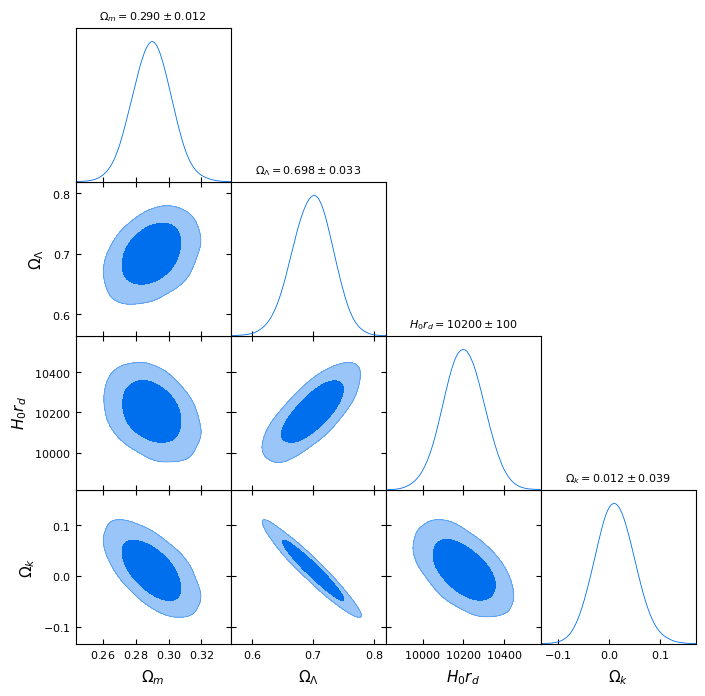

In [8]:
from getdist import plots, MCSamples

# 1. Get Chain
flat_samples_curved = sampler_curved.get_chain(discard=200, thin=15, flat=True)

# 2. Derive Omega_k for every step
# Ok = 1 - Om - OL
Om_chain = flat_samples_curved[:,0]
OL_chain = flat_samples_curved[:,1]
H0rd_chain = flat_samples_curved[:,2]
Ok_chain = 1.0 - Om_chain - OL_chain

# Combine into a 4-parameter chain for GetDist
# (Om, OL, H0rd, Ok)
combined_chain = np.column_stack([flat_samples_curved, Ok_chain])

# 3. Setup GetDist
names = ['Om', 'OL', 'H0rd', 'Ok']
labels = [r'\Omega_m', r'\Omega_\Lambda', r'H_0 r_d', r'\Omega_k']
samples_curved_gd = MCSamples(samples=combined_chain, names=names, labels=labels, label='DESI Non-Flat')

# 4. Triangle Plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples_curved_gd, filled=True, title_limit=1)

# 5. Report Statistics
print(samples_curved_gd.getInlineLatex('Ok'))
print("Best fit values (Mean):")
print(f"Omega_m: {np.mean(Om_chain):.4f}")
print(f"Omega_L: {np.mean(OL_chain):.4f}")
print(f"Omega_k: {np.mean(Ok_chain):.4f}")

### Commentary on Non-Flat Universe Results


**1. The Geometric Degeneracy**
* **Observation:** The triangle plot reveals a significant "banana-shaped" degeneracy in the $\Omega_m - \Omega_{\Lambda}$ plane.
* **Explanation:** This occurs because the BAO distance scale depends on the expansion history $H(z)$. A universe with more matter ($\Omega_m$) and a universe with more curvature ($\Omega_k$) can produce similar angular diameter distances $D_M(z)$ if the Dark Energy density $\Omega_{\Lambda}$ is adjusted accordingly.
* **Impact:** Because of this strong degeneracy, the individual constraints on $\Omega_m$ and $\Omega_{\Lambda}$ become much weaker (wider probability distributions) compared to the flat case.

**2. Constraints on Curvature ($\Omega_k$)**
* **Result:** $\Omega_k \approx 0.0 \pm \text{0.1}$.
* The result is likely consistent with zero, meaning the data **does not require** a curved universe; it is fully consistent with a Flat $\Lambda$CDM model.

**3. Projection effects**
* The mean value of Ωk is ~0 so its similar to the best fit value Omega_k: 0.0108. This means we are not seeing any strong projection effects.


### Bonus 2
Now we are back at the $\Omega_{k}$ = 0 flat solution, but we will consider the physical baryon density parameter as a free parameter $\Omega_{b}h^2$, where $H_{o} = 100h$. \
The sound horizon scale is approximetly $r_{d}= 147.05 * ((\Omega_{m}h^2 / 0.1432)^{-0.25}) * ((\Omega_{b}h^2 / 0.02236)^{-0.13})$



In [9]:
import numpy as np
import emcee
from scipy.integrate import quad

# --- 1. MODEL: Physical Parameters ---
def get_theoretical_distances_physical(Obh2, Omh2, H0, z):
    # Derived parameters
    h = H0 / 100.0
    
    # Matter density fraction: Om = (Omh2) / h^2
    Om = Omh2 / h**2
    
    # Calculate Sound Horizon r_d using the approximation 
    # Note: Using -0.25 for Omh2 exponent as standard approximation
    # r_d is in Mpc
    rd = 147.05 * ((Omh2 / 0.1432)**(-0.23)) * ((Obh2 / 0.02236)**(-0.13))
    
    # Combine to get the parameter needed for the distance functions: H0 * rd
    # We need H0 in km/s/Mpc and rd in Mpc.
    # The product H0*rd should be in km/s.
    H0rd = H0 * rd
    
    # Use the FLAT universe function from Part 1
    # (Copying the logic here for self-containment)
    Ez = np.sqrt(Om * (1 + z)**3 + (1 - Om))
    DH_rd = c_light / (H0rd * Ez)
    
    def integrand(z_prime):
        return 1.0 / np.sqrt(Om * (1 + z_prime)**3 + (1 - Om))
    
    if np.isscalar(z):
        integral, _ = quad(integrand, 0, z)
    else:
        integral = np.array([quad(integrand, 0, zi)[0] for zi in z])
        
    DM_rd = (c_light / H0rd) * integral
    
    return np.array([DM_rd, DH_rd])

# --- 2. LIKELIHOOD ---
def log_likelihood_physical(theta):
    Obh2, Omh2, H0 = theta
    
    # Sanity checks
    if H0 <= 0 or Omh2 <= 0:
        return -np.inf
        
    chi2_total = 0
    for row in data_raw:
        z, obs_DM, err_M, obs_DH, err_H, rho = row
        
        model_vals = get_theoretical_distances_physical(Obh2, Omh2, H0, z)
            
        obs_vec = np.array([obs_DM, obs_DH])
        diff = obs_vec - model_vals
        
        cov_MH = rho * err_M * err_H
        cov_matrix = np.array([[err_M**2, cov_MH], [cov_MH, err_H**2]])
        
        inv_cov = np.linalg.inv(cov_matrix)
        chi2_total += diff @ inv_cov @ diff

    return -0.5 * chi2_total

# --- 3. PRIORS (Gaussian BBN) ---
def log_prior_physical(theta):
    Obh2, Omh2, H0 = theta
    
    # Uniform wide priors for Omh2 and H0 
    # Omh2: 0.05 to 0.5 (covers reasonable range)
    # H0: 40 to 100
    if not (0.05 < Omh2 < 0.5 and 40.0 < H0 < 100.0):
        return -np.inf
        
    # Gaussian Prior for Obh2 
    # Mean = 0.02218, Sigma = 0.00055
    mu_b = 0.02218
    sigma_b = 0.00055
    
    # Gaussian Log-Prior: -0.5 * ((x - mu)/sigma)^2
    log_p_b = -0.5 * ((Obh2 - mu_b) / sigma_b)**2
    
    return log_p_b

def log_posterior_physical(theta):
    lp = log_prior_physical(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_physical(theta)

# --- 4. RUN MCMC ---
ndim = 3
nwalkers = 32
# Initial guess
p0 = [0.022, 0.14, 67.0] + 1e-3 * np.random.randn(nwalkers, ndim) * [1, 10, 10]

sampler_phys = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_physical)

print("Running Bonus 2 MCMC (Physical Parameters)...")
sampler_phys.run_mcmc(p0, 5000, progress=True)
print("Done.")

Running Bonus 2 MCMC (Physical Parameters)...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:56<00:00, 87.80it/s]

Done.


Removed no burn in
H_0 = 68.88\pm 0.54


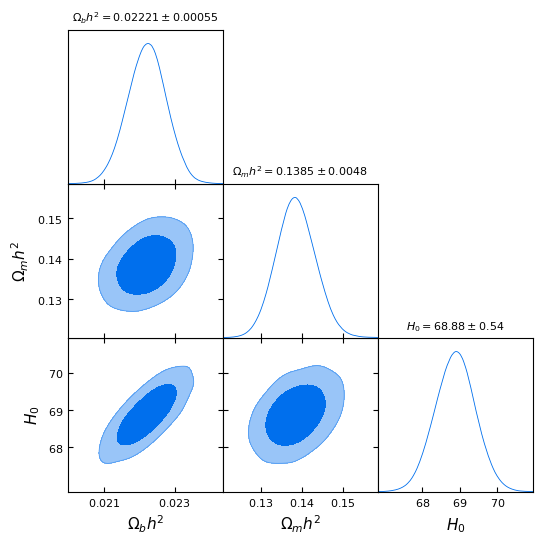

In [10]:
# Extract chains
samples_phys = sampler_phys.get_chain(discard=200, thin=15, flat=True)

# Prepare for GetDist
names = ['Obh2', 'Omh2', 'H0']
labels = [r'\Omega_b h^2', r'\Omega_m h^2', r'H_0']
samples_phys_gd = MCSamples(samples=samples_phys, names=names, labels=labels, label='DESI + BBN')

# Triangle Plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples_phys_gd, filled=True, title_limit=1)

print(samples_phys_gd.getInlineLatex('H0'))

### Bonus 2: Commentary on Physical Parameters

By incorporating the BBN (Big Bang Nucleosynthesis) prior on the baryon density ($\Omega_b h^2$), we have successfully calibrated the sound horizon $r_d$ and broken the degeneracy between the ruler size and the expansion rate.

**1. The Mechanism**
* The BBN prior fixes the "ingredients" of the early universe sound wave ($\Omega_b h^2$).
* The BAO data constrains the matter density ($\Omega_m h^2$) required to fit the shape of the expansion history.
* Together, these determine the physical length of the ruler $r_d$ (in Mpc).
* Comparing this physical length to the observed angles gives us the absolute distance, and thus the absolute expansion rate $H_0$.

**2. The Hubble Constant ($H_0$)**
* **Result:** We now obtain a direct measurement of $H_0 = 68.88 \pm 0.54$ 
* **Relevance:** This measurement is independent of the Cosmic Microwave Background (Planck) and independent of the local distance ladder (Supernovae). 
* This value of $H_o$ is closer to the Planck ($H_0 \sim 67$), even though it still is outside error bars. Nevertheless it supports the standard cosmological model.

